In [2]:
# py -3.11 -m venv venv
# .\venv\Scripts\Activate.ps1
# python -m pip install --upgrade pip setuptools wheel
# python -m pip install ipykernel
# python -m ipykernel install --user --name ai-service-venv --display-name "Python (ai-service venv)"
# Select Kernel -> Python (ai-service venv)
import sys
print(sys.version)
print(sys.executable)
# python -m pip install -r requirements.txt
print("Hello World")

3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
e:\SmartStudyRoom\ai-service\venv\Scripts\python.exe
Hello World


# **Pipeline Phân Loại Văn Bản sử dụng TF-IDF và Logistic Regression**
--------

## ***Tổng quan***

Tài liệu này trình bày một quy trình hoàn chỉnh nhằm xây dựng và đánh giá mô hình phân loại văn bản tiếng Việt, từ giai đoạn phân tích dữ liệu ban đầu cho đến tối ưu và đánh giá mô hình. Trọng tâm không chỉ nằm ở việc triển khai pipeline, mà còn ở việc giải thích rõ ràng lý do lựa chọn từng phương pháp và ý nghĩa của các kết quả thu được.

Bài toán đặt ra là phân loại các câu văn bản tiếng Việt vào các nhóm nhãn xác định trước. Đây là một dạng bài toán phổ biến trong xử lý ngôn ngữ tự nhiên (NLP), nơi chất lượng mô hình phụ thuộc mạnh vào cách biểu diễn văn bản và mức độ làm sạch dữ liệu đầu vào.

Quy trình bắt đầu bằng việc tải dataset và thực hiện phân tích khám phá dữ liệu (Exploratory Data Analysis - EDA). Mục tiêu của bước này là đánh giá chất lượng dữ liệu, bao gồm kiểm tra dữ liệu thiếu, trùng lặp, phân bố nhãn, độ dài văn bản và các yếu tố nhiễu. Những quan sát từ EDA đóng vai trò định hướng cho các bước xử lý tiếp theo, đặc biệt là thiết kế pipeline tiền xử lý.

Sau đó, dữ liệu được chuẩn hóa thông qua một pipeline tiền xử lý văn bản. Pipeline này bao gồm các bước: chuyển về chữ thường, loại bỏ dấu câu, chuẩn hóa từ viết tắt, tách từ bằng thư viện underthesea và loại bỏ stopwords. Việc tiền xử lý nhằm giảm nhiễu, chuẩn hóa biểu diễn và đặc biệt quan trọng trong tiếng Việt do đặc thù không thể tách từ đơn giản bằng khoảng trắng.

Tiếp theo, văn bản được chuyển thành biểu diễn số thông qua TF-IDF với cả unigram và bigram. Cách biểu diễn này giúp mô hình nắm bắt được cả từ đơn lẫn các cụm từ mang ý nghĩa hành động. Tuy nhiên, không phải tất cả đặc trưng đều hữu ích, do đó phương pháp Chi-Square được sử dụng để chọn ra những đặc trưng có khả năng phân biệt nhãn tốt nhất, giúp giảm nhiễu và cải thiện khả năng tổng quát hóa của mô hình.

Mô hình được sử dụng là Logistic Regression, một lựa chọn hiệu quả cho bài toán phân loại văn bản với dữ liệu dạng sparse. Quá trình tối ưu siêu tham số được thực hiện theo chiến lược hai giai đoạn:

- Sử dụng RandomizedSearchCV để khảo sát nhanh không gian tham số và xác định vùng tham số tiềm năng.
- Sau đó áp dụng GridSearchCV trong phạm vi hẹp hơn để tìm bộ tham số tối ưu.

Chiến lược này giúp cân bằng giữa chi phí tính toán và khả năng tìm kiếm nghiệm tốt.

Cuối cùng, mô hình được huấn luyện lại với tham số tối ưu và đánh giá trên tập test. Các chỉ số như Accuracy, Precision, Recall, F1-score và Confusion Matrix được sử dụng để đánh giá hiệu năng. Bên cạnh đó, các kỹ thuật trực quan hóa cũng được áp dụng để hỗ trợ phân tích dữ liệu và diễn giải kết quả mô hình.

## ***Mục lục***
1. Thiết lập môi trường
2. Phân tích dữ liệu (EDA)
3. Tiền xử lý văn bản
4. Trích xuất và chọn đặc trưng
5. Huấn luyện mô hình (Random Search + Grid Search)
6. Đánh giá mô hình
7. Dự đoán trên dữ liệu mới

# **1. Thiết lập mô trường**
--------

Phần này tập trung xây dựng môi trường thực thi nhất quán và có khả năng tái lập cho toàn bộ pipeline. Các bước bao gồm import các thư viện cần thiết, kiểm tra và tự động cài đặt các dependency còn thiếu, cũng như thiết lập công cụ xử lý văn bản tiếng Việt. Việc chuẩn hóa môi trường ngay từ đầu giúp đảm bảo toàn bộ quy trình có thể chạy ổn định trên các phiên làm việc khác nhau mà không phát sinh lỗi do thiếu thư viện hoặc sai cấu hình.

## ***1.1. Import thư viện xử lý dữ liệu và trực quan hóa***

Chuẩn bị các công cụ cần thiết cho việc xử lý dữ liệu, tiền xử lý văn bản, trích xuất đặc trưng và đánh giá mô hình trong toàn bộ pipeline. Cụ thể:

- `pandas`, `numpy`: xử lý và thao tác dữ liệu dạng bảng và mảng số.
- `re`: xử lý văn bản bằng biểu thức chính quy (phục vụ làm sạch text).
- `matplotlib`, `seaborn`: trực quan hóa dữ liệu trong giai đoạn EDA và đánh giá.
- `Counter`: thống kê tần suất từ, hỗ trợ phân tích dữ liệu văn bản.
- `TfidfVectorizer`: chuyển đổi văn bản thành vector đặc trưng.
- `PCA`: hỗ trợ giảm chiều (phục vụ trực quan hóa).
- `LogisticRegression`: mô hình phân loại chính.
- `RandomizedSearchCV`, `GridSearchCV`: tối ưu siêu tham số.
- Các metric (`accuracy_score`, `classification_report`, `confusion_matrix`): đánh giá hiệu năng mô hình.

In [3]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, train_test_split
from sklearn.feature_selection import SelectKBest, SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from scipy.stats import uniform, loguniform

## ***1.2. Cài đặt và import tokenizer tiếng Việt***

Đảm bảo văn bản tiếng Việt được tách từ (tokenization) một cách chính xác trước khi đưa vào bước trích xuất đặc trưng. Khác với tiếng Anh, tiếng Việt là ngôn ngữ đa âm tiết, trong đó một từ có thể bao gồm nhiều đơn vị được ngăn cách bởi dấu cách. Do đó, việc tách từ dựa trên khoảng trắng sẽ dẫn đến sai lệch về mặt ngữ nghĩa.

Ví dụ với câu “học sinh giỏi”:

- Tách theo khoảng trắng: ["học", "sinh", "giỏi"] $→$ làm mất nghĩa của cụm “học sinh”.
- Tách đúng: ["học_sinh", "giỏi"] $→$ giữ nguyên đơn vị ngữ nghĩa.

Nếu tokenization không chính xác:

- Các cụm từ quan trọng bị phân mảnh
- Số lượng đặc trưng tăng nhưng thông tin giảm (sparse và noisy)
- TF-IDF không phản ánh đúng ý nghĩa văn bản
- Hiệu năng mô hình bị suy giảm

Vì vậy, việc sử dụng một tokenizer chuyên biệt cho tiếng Việt như `underthesea` là bước quan trọng trong pipeline.

In [4]:
from underthesea import word_tokenize

# **2. EDA**
--------

Phần này nhằm đánh giá chất lượng và đặc điểm của dataset trước khi đưa vào huấn luyện mô hình. Các bước phân tích bao gồm kiểm tra dữ liệu thiếu và trùng lặp, phân bố nhãn, độ dài văn bản, cũng như các yếu tố nhiễu như ký tự đặc biệt hoặc từ vựng bất thường. Mục tiêu của EDA không chỉ là mô tả dữ liệu, mà còn để phát hiện các vấn đề tiềm ẩn có thể ảnh hưởng đến mô hình, từ đó định hướng cho các bước tiền xử lý và lựa chọn đặc trưng ở các phần tiếp theo.

Nguồn dữ liệu: [link dataset](https://)

## ***2.1. Tổng quan dữ liệu***

Đánh giá sơ bộ cấu trúc và tính hợp lệ của dataset trước khi tiến hành các bước xử lý và huấn luyện mô hình.

Chất lượng dữ liệu đầu vào ảnh hưởng trực tiếp đến hiệu năng mô hình. Việc kiểm tra kích thước, kiểu dữ liệu và sự đầy đủ của dataset giúp phát hiện sớm các vấn đề như dữ liệu thiếu, sai định dạng hoặc cấu trúc không nhất quán, từ đó tránh lỗi trong các bước xử lý tiếp theo.

In [9]:
df = pd.read_csv("data/raw_dataset_v1.csv")

print("Kích thước:", df.shape)

print("\nThông tin:")
print(df.info())

print("\n10 dòng đầu:")
print(df.head(10))

Kích thước: (2400, 2)

Thông tin:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   du_lieu  2400 non-null   object
 1   nhan     2400 non-null   object
dtypes: object(2)
memory usage: 37.6+ KB
None

10 dòng đầu:
                                            du_lieu      nhan
0               giúp mình mở quạt để dễ chịu hơn đi  bat_quat
1            giúp tôi tôi muốn không khí thoáng hơn  bat_quat
2    giúp mình ngột ngạt quá, cho mát hơn giúp mình  bat_quat
3                         giúp tôi gió mạnh quá với  tat_quat
4                      làm ơn tắt quạt bàn để đỡ ồn  tat_quat
5             này, đủ mát rồi, cho quạt nghỉ đi với  tat_quat
6                     này, anh thấy chói mắt quá đi   tat_den
7          này, ánh sáng yếu quá, tăng sáng lên nhé   bat_den
8  giúp mình mồ hôi bắt đầu ra rồi, cho mát hơn nhé  bat_quat
9                 mình muốn ngủ,

**Kết quả:**
- Dataset gồm 2400 mẫu và 2 cột:
  - du_lieu: văn bản đầu vào.
  - nhan: nhãn phân loại.
- Không có giá trị thiếu (2400/2400 non-null cho cả hai cột).
- Kiểu dữ liệu của cả hai cột là object, phù hợp với dữ liệu văn bản.
- Các mẫu đầu cho thấy dữ liệu là các câu lệnh tiếng Việt mang tính yêu cầu (ví dụ bật/tắt thiết bị).

**Nhận xét:**

Dataset có cấu trúc rõ ràng, không có dữ liệu thiếu và sẵn sàng cho các bước xử lý tiếp theo. Tuy nhiên, việc cả hai cột đều ở dạng object cho thấy cần thực hiện tiền xử lý văn bản để chuẩn hóa dữ liệu trước khi trích xuất đặc trưng. Đồng thời, việc quan sát nội dung ban đầu cũng gợi ý rằng bài toán có thể dựa nhiều vào các từ khóa hành động, điều này sẽ được kiểm chứng ở các bước EDA tiếp theo.

## ***2.2. Kiểm tra dữ liệu khuyết***

Xác định xem dataset có tồn tại giá trị thiếu hoặc dữ liệu không hợp lệ (ví dụ chuỗi rỗng) hay không.

Dữ liệu khuyết hoặc rỗng có thể gây lỗi trong các bước tiền xử lý (đặc biệt là tokenization) và làm sai lệch quá trình huấn luyện mô hình. Việc kiểm tra sớm giúp đảm bảo dữ liệu đầu vào sạch và tránh các xử lý bổ sung không cần thiết.

In [10]:
print("Giá trị thiếu:")
print(df.isnull().sum())

empty_text = df[df["du_lieu"].str.strip() == ""]
print("\nSố câu rỗng:", len(empty_text))

Giá trị thiếu:
du_lieu    0
nhan       0
dtype: int64

Số câu rỗng: 0


**Kết quả:**

- Không có giá trị thiếu ở cả hai cột (du_lieu, nhan).
- Không tồn tại câu rỗng trong dataset.

**Nhận xét:**

Dataset đầy đủ và không chứa dữ liệu khuyết, do đó không cần thực hiện các bước xử lý missing data. Điều này giúp đơn giản hóa pipeline và đảm bảo toàn bộ dữ liệu có thể được sử dụng trực tiếp cho các bước phân tích và huấn luyện tiếp theo.

## ***2.3. Kiểm tra trùng lặp***

Đảm bảo dataset không chứa các mẫu trùng lặp hoặc các trường hợp xung đột nhãn có thể ảnh hưởng đến quá trình huấn luyện mô hình.

Dữ liệu trùng lặp có thể làm sai lệch phân phối dữ liệu, khiến mô hình “học thuộc” thay vì học khái quát. Nguy hiểm hơn, nếu cùng một câu xuất hiện với nhiều nhãn khác nhau (label conflict), mô hình sẽ nhận tín hiệu mâu thuẫn, dẫn đến giảm hiệu năng và khó hội tụ.

In [11]:
print("Số dòng trùng:", df.duplicated().sum())

dup_text = df.groupby("du_lieu")["nhan"].nunique()
conflict = dup_text[dup_text > 1]

print("Số mẫu xung đột nhãn:", len(conflict))

Số dòng trùng: 0
Số mẫu xung đột nhãn: 0


**Kết quả:**

- Không có dòng trùng lặp.
- Không tồn tại trường hợp cùng một văn bản nhưng có nhiều nhãn khác nhau.

**Nhận xét:**

Dataset có tính nhất quán cao, không chứa nhiễu do trùng lặp hoặc xung đột nhãn. Điều này đảm bảo mô hình nhận được tín hiệu học rõ ràng, góp phần cải thiện khả năng hội tụ và độ tin cậy của kết quả huấn luyện.

## ***2.4. Phân bố nhãn***

Đánh giá sự phân bố số lượng mẫu giữa các lớp để xác định mức độ cân bằng của bài toán phân loại.

Phân bố nhãn ảnh hưởng trực tiếp đến cách đánh giá và huấn luyện mô hình. Nếu dữ liệu bị mất cân bằng (class imbalance), mô hình có thể thiên lệch về các lớp chiếm đa số, dẫn đến accuracy cao nhưng hiệu năng thực tế kém. Ngược lại, dữ liệu cân bằng giúp mô hình học đều các lớp và cho kết quả đánh giá đáng tin cậy hơn.

nhan
bat_quat    600
tat_quat    600
tat_den     600
bat_den     600
Name: count, dtype: int64


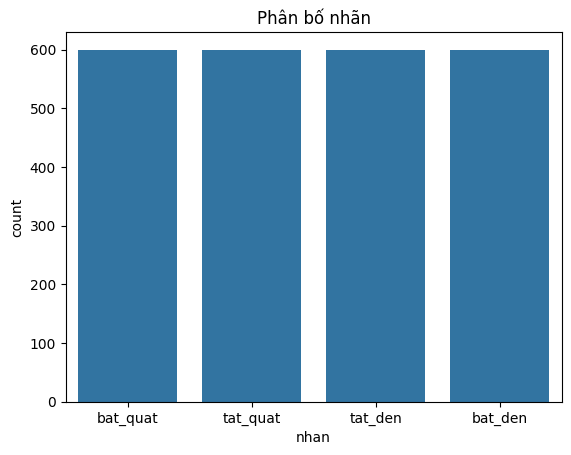

In [12]:
print(df["nhan"].value_counts())

sns.countplot(x="nhan", data=df)
plt.title("Phân bố nhãn")
plt.show()

**Kết quả:**

- Dataset gồm 4 lớp: `bat_quat`, `tat_quat`, `bat_den`, `tat_den`.
- Mỗi lớp có 600 mẫu, tổng cộng 2400 mẫu.
- Biểu đồ cho thấy các lớp có phân bố hoàn toàn đồng đều.

**Nhận xét:**

Dataset có phân bố nhãn cân bằng, đây là một điều kiện thuận lợi cho quá trình huấn luyện. Mô hình không cần áp dụng các kỹ thuật xử lý mất cân bằng như re-sampling hay class weighting. Đồng thời, các chỉ số như accuracy có thể được sử dụng như một thước đo tổng quát mà không bị lệch do phân bố dữ liệu.

## ***2.5. Phân tích độ dài câu***

Phân tích phân bố độ dài văn bản nhằm hiểu đặc điểm dữ liệu và hỗ trợ các quyết định trong tiền xử lý và biểu diễn đặc trưng.

Độ dài câu ảnh hưởng trực tiếp đến cách biểu diễn văn bản và hiệu năng mô hình. Các câu quá ngắn có thể thiếu thông tin ngữ nghĩa, trong khi các câu quá dài có thể chứa nhiều nhiễu. Việc nắm được phân bố độ dài giúp:

- Xác định xem dữ liệu có đồng nhất hay không
- Phát hiện outliers (câu quá ngắn hoặc quá dài)
- Định hướng các tham số như max_features, n-gram hoặc giới hạn độ dài đầu vào

count    2400.000000
mean        8.400000
std         2.098055
min         2.000000
25%         7.000000
50%         8.000000
75%        10.000000
max        15.000000
Name: do_dai, dtype: float64


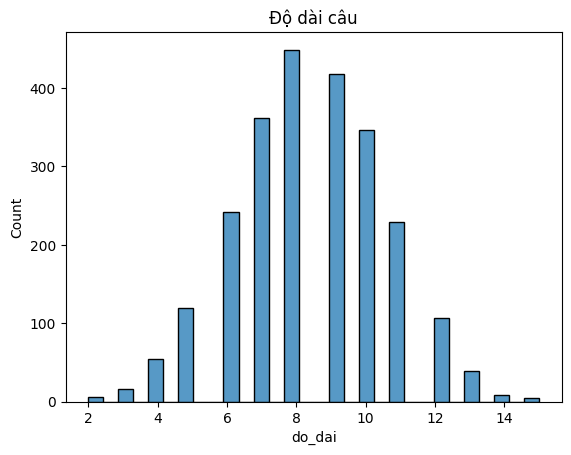

In [13]:
df["do_dai"] = df["du_lieu"].apply(lambda x: len(x.split()))

print(df["do_dai"].describe())

sns.histplot(df["do_dai"], bins=30)
plt.title("Độ dài câu")
plt.show()

**Kết quả:**

- Số mẫu: 2400.
- Độ dài trung bình: ~8 từ.
- Độ lệch chuẩn: ~2.1
- Min: 2 từ, Max: 15 từ.
- Phần lớn câu nằm trong khoảng 6–11 từ
- Biểu đồ histogram cho thấy phân bố tập trung quanh vùng trung bình, không có nhiều giá trị ngoại lai.

**Nhận xét:**

Dataset có độ dài câu tương đối đồng đều, chủ yếu là các câu ngắn mang tính mệnh lệnh hoặc yêu cầu. Điều này phù hợp với việc sử dụng TF-IDF với unigram và bigram, vì các cụm từ quan trọng thường ngắn và rõ nghĩa. Ngoài ra, việc không có nhiều outlier giúp giảm nhu cầu xử lý cắt ngắn hoặc padding, giữ cho pipeline đơn giản và hiệu quả.

## ***2.6. Phân tích từ vựng tổng thể***

Khám phá đặc điểm từ vựng của toàn bộ dataset nhằm hiểu mức độ đa dạng ngôn ngữ và xác định các từ phổ biến. Việc phân tích tần suất từ giúp:

- Đánh giá độ phong phú của từ vựng (vocabulary size).
- Xác định các từ xuất hiện nhiều nhưng ít giá trị phân biệt (ví dụ: từ chung, từ đệm).
- Định hướng cho bước tiền xử lý như loại bỏ từ dừng (stopwords) hoặc lựa chọn đặc trưng.

In [14]:
all_words = " ".join(df["du_lieu"]).lower().split()
word_counts = Counter(all_words)

print("Số từ khác nhau:", len(word_counts))
print("\nTop 20 từ phổ biến:")
print(word_counts.most_common(20))

Số từ khác nhau: 212

Top 20 từ phổ biến:
[('giúp', 1373), ('mình', 1311), ('tôi', 1043), ('quạt', 1023), ('đi', 726), ('đèn', 666), ('sáng', 615), ('hộ', 583), ('tắt', 471), ('quá,', 460), ('cần', 447), ('làm', 435), ('hơn', 412), ('mở', 390), ('này,', 381), ('ơi,', 377), ('cho', 373), ('để', 371), ('ơn', 369), ('bật', 347)]


**Kết quả:**

- Tổng số từ khác nhau: 212.
- Các từ xuất hiện nhiều nhất bao gồm: “giúp”, “mình”, “tôi”, “quạt”, “đi”, “đèn”, “sáng”, “tắt”,...

**Nhận xét:**

Từ vựng của dataset tương đối nhỏ và tập trung, phản ánh đặc thù của bài toán với các câu lệnh ngắn và cấu trúc lặp lại. Nhiều từ phổ biến là từ chung (ví dụ: “giúp”, “mình”, “tôi”) không mang nhiều thông tin phân biệt giữa các lớp. Điều này cho thấy việc áp dụng TF-IDF là phù hợp, vì phương pháp này sẽ tự động giảm trọng số của các từ xuất hiện quá thường xuyên và làm nổi bật các từ có giá trị phân loại cao hơn.

## ***2.7. Từ khóa theo từng nhãn***

Xác định các từ đặc trưng (discriminative features) của từng lớp nhằm hiểu cách dữ liệu phân biệt giữa các nhãn.

Trong bài toán phân loại văn bản, đặc biệt với TF-IDF, mô hình học dựa trên sự khác biệt về từ vựng giữa các lớp. Việc phân tích từ khóa theo từng nhãn giúp:

- Hiểu rõ “tín hiệu” mà mô hình sẽ học.
- Kiểm tra xem các lớp có đủ khác biệt hay không.
- Phát hiện nguy cơ shortcut learning (mô hình chỉ dựa vào vài từ khóa đơn giản).

In [15]:
for label in df["nhan"].unique():
    text = " ".join(df[df["nhan"] == label]["du_lieu"]).lower()
    words = text.split()
    counts = Counter(words)

    print(f"\n=== {label} ===")
    print(counts.most_common(20))


=== bat_quat ===
[('quạt', 376), ('giúp', 348), ('mình', 314), ('tôi', 263), ('bật', 184), ('mở', 179), ('cần', 161), ('hơn', 153), ('hộ', 149), ('đi', 118), ('phòng', 115), ('mát', 111), ('để', 108), ('này,', 101), ('làm', 95), ('ơi,', 95), ('ơn', 90), ('quá,', 88), ('cho', 87), ('nhé', 74)]

=== tat_quat ===
[('quạt', 647), ('giúp', 343), ('mình', 332), ('tắt', 259), ('đi', 258), ('tôi', 253), ('quá,', 140), ('hộ', 137), ('không', 125), ('làm', 124), ('lạnh', 111), ('cần', 106), ('cho', 103), ('này,', 97), ('ơn', 96), ('ơi,', 96), ('nữa', 93), ('muốn', 90), ('nghỉ', 77), ('với', 76)]

=== tat_den ===
[('sáng', 371), ('mình', 340), ('giúp', 336), ('đèn', 329), ('tôi', 263), ('đi', 250), ('tắt', 212), ('ánh', 197), ('hộ', 156), ('quá,', 140), ('làm', 110), ('mắt', 109), ('bớt', 97), ('cho', 93), ('chói', 92), ('ơn', 92), ('ơi,', 90), ('này,', 89), ('lại', 88), ('hơn', 86)]

=== bat_den ===
[('giúp', 346), ('đèn', 337), ('mình', 325), ('tôi', 264), ('sáng', 244), ('mở', 211), ('bật', 1

**Kết quả:** mỗi nhãn có các từ khóa đặc trưng rõ ràng:

- `bat_quat`: “quạt”, “bật”, “mở”, “mát”.
- `tat_quat`: “quạt”, “tắt”, “lạnh”, “nghỉ”.
- `bat_den`: “đèn”, “bật”, “mở”, “sáng”, “học”.
- `tat_den`: “đèn”, “tắt”, “chói”, “mắt”, “bớt”.
- Bên cạnh đó, nhiều từ xuất hiện ở mọi lớp như “giúp”, “mình”, “tôi”, “hộ”.

**Nhận xét:**

Các lớp có sự phân tách rõ ràng dựa trên từ khóa hành động (“bật” vs “tắt”) và đối tượng (“quạt” vs “đèn”). Đây là một tín hiệu mạnh giúp mô hình dễ dàng học và đạt hiệu năng cao.

Tuy nhiên, điều này cũng cho thấy bài toán có xu hướng dựa nhiều vào các lexical cues đơn giản. Nếu dữ liệu thực tế có cách diễn đạt đa dạng hơn (ví dụ không dùng trực tiếp từ “bật” hoặc “tắt”), mô hình có thể gặp khó khăn trong việc tổng quát hóa.

## ***2.8. Từ đặc trưng riêng từng nhãn (phát hiện shortcut)***

Xác định các từ chỉ xuất hiện trong một nhãn duy nhất nhằm phát hiện các tín hiệu phân loại mạnh (potential shortcuts) trong dữ liệu.

Nếu tồn tại các từ chỉ xuất hiện ở một lớp duy nhất, mô hình có thể dựa hoàn toàn vào các từ này để dự đoán mà không cần học ngữ nghĩa tổng thể. Hiện tượng này gọi là shortcut learning — mô hình đạt hiệu năng cao nhưng khả năng tổng quát hóa kém khi gặp dữ liệu mới.

Việc phát hiện các từ đặc trưng riêng giúp:

- Đánh giá mức độ “dễ” của bài toán.
- Hiểu rõ các tín hiệu mà mô hình sẽ tận dụng.
- Nhận diện rủi ro overfitting vào từ khóa.

In [16]:
label_vocab = {}

for label in df["nhan"].unique():
    words = " ".join(df[df["nhan"] == label]["du_lieu"]).lower().split()
    label_vocab[label] = set(words)

for label in label_vocab:
    others = set.union(*(label_vocab[l] for l in label_vocab if l != label))
    exclusive = label_vocab[label] - others

    print(f"\nTừ chỉ có ở {label}:")
    print(list(exclusive)[:20])


Từ chỉ có ở bat_quat:
['ngột', 'thở', 'tục', 'ngay.', 'đổ', 'thoáng,', 'quạt!', 'nóng', 'chép!', 'bí', 'nực', 'khí', 'ngạt,', 'ngạt', 'chịu!', 'bách', 'oi', 'hôi,', 'điện.', 'ra']

Từ chỉ có ở tat_quat:
['ngừng', 'trung,', 'kêu', 'dừng', 'người', 'đừng', 'lạnh', 'tĩnh', 'lùa', 'chạy', 'yên', 'lạnh,', 'thổi', 'mặt', 'chịu,', 'thôi', 'to', 'to,', 'nghỉ.', 'tâm,']

Từ chỉ có ở tat_den:
['chợp', 'mỏi', 'quá!', 'sáng.', 'chỉ', 'xong', 'ngủ,', 'ngủ', 'gắt,', 'gắt', 'chói,', 'dịu', 'thôi,', 'chuẩn', 'giảm', 'sắp', 'gây', 'bớt', 'bị', 'ngơi']

Từ chỉ có ở bat_den:
['sáng!', 'sách.', 'chưa', 'rõ!', 'phòng!', 'học!', 'thêm', 'yếu', 'thật!', 'học.', 'rõ,', 'học,', 'nhìn', 'tăng', 'đèn!', 'trời', 'thiếu', 'rõ', 'liệu.', 'thế']


**Kết quả:** mỗi nhãn có một tập các từ chỉ xuất hiện riêng, ví dụ:

- `bat_quat`: các từ liên quan đến cảm giác nóng, ngột ngạt. (“nóng”, “ngạt”, “thoáng”,...)
- `tat_quat`: các từ liên quan đến lạnh hoặc dừng hoạt động. (“lạnh”, “ngừng”, “to”,...)
- `tat_den`: các từ liên quan đến ánh sáng gây khó chịu. (“chói”, “gắt”, “mắt”,...)
- `bat_den`: các từ liên quan đến nhu cầu ánh sáng. (“học”, “tối”, “thiếu”...).

**Nhận xét:**

Sự tồn tại của các từ đặc trưng riêng cho từng nhãn cho thấy dataset có tín hiệu phân loại rất rõ ràng. Đây là một lợi thế giúp mô hình dễ đạt hiệu năng cao.

Tuy nhiên, điều này cũng xác nhận nguy cơ shortcut learning: mô hình có thể chỉ cần học các từ khóa đặc trưng mà không cần hiểu đầy đủ ngữ cảnh. Trong các tình huống thực tế, nơi cách diễn đạt đa dạng hơn hoặc không chứa các từ khóa này, hiệu năng mô hình có thể suy giảm đáng kể.

Do đó, kết quả ở bước này cần được xem xét cẩn thận khi diễn giải các chỉ số đánh giá ở các phần sau.

## ***2.9. Kiểm tra độ mơ hồ (câu ngắn / khó)***

Xác định các câu có độ dài rất ngắn nhằm đánh giá mức độ mơ hồ và khả năng gây nhiễu trong quá trình huấn luyện.

Các câu quá ngắn thường thiếu ngữ cảnh và có thể không chứa đủ thông tin để phân loại chính xác. Trong nhiều trường hợp, những câu này dễ gây nhầm lẫn giữa các lớp hoặc buộc mô hình phải dựa vào các tín hiệu rất yếu. Việc kiểm tra giúp:

- Đánh giá mức độ “khó” của dataset.
- Xác định xem có cần loại bỏ hoặc xử lý riêng các câu này hay không.
- Hiểu rõ giới hạn của mô hình khi gặp dữ liệu thiếu ngữ cảnh.

In [17]:
short_sentences = df[df["do_dai"] <= 2]

print("Số câu rất ngắn:", len(short_sentences))
print(short_sentences.head(20))

Số câu rất ngắn: 6
        du_lieu      nhan  do_dai
201   lạnh quá.  tat_quat       2
559   sáng quá!   tat_den       2
587     Mát rồi  tat_quat       2
601      Bí quá  bat_quat       2
1379    Gắt quá   tat_den       2
1788     Mờ quá   bat_den       2


**Kết quả:**

- Tổng cộng 6 câu rất ngắn trong toàn bộ dataset.
- Các câu tiêu biểu: “lạnh quá”, “sáng quá”, “bí quá”, “mở quá”,...

**Nhận xét:**

Số lượng câu ngắn là rất nhỏ so với tổng dataset (2400 mẫu), do đó ảnh hưởng đến mô hình là không đáng kể. Tuy nhiên, các câu này mang tính mơ hồ vì thiếu ngữ cảnh rõ ràng và có thể phụ thuộc nhiều vào cách diễn giải.

Dù không cần xử lý riêng trong pipeline hiện tại, việc nhận diện các trường hợp này giúp hiểu rõ hơn về giới hạn của mô hình, đặc biệt khi áp dụng vào dữ liệu thực tế có thể chứa nhiều câu ngắn hoặc không đầy đủ thông tin hơn.

## ***2.10. Phân bố độ dài theo nhãn***

So sánh độ dài câu giữa các nhãn nhằm xác định liệu có sự khác biệt về cấu trúc văn bản giữa các lớp hay không.

Nếu một số nhãn có xu hướng dài hoặc ngắn hơn đáng kể, mô hình có thể vô tình học các đặc trưng về độ dài thay vì nội dung. Việc phân tích này giúp:

- Phát hiện bias tiềm ẩn theo độ dài câu.
- Kiểm tra tính đồng nhất giữa các lớp.
- Đánh giá xem độ dài có phải là một tín hiệu phân loại hay không.

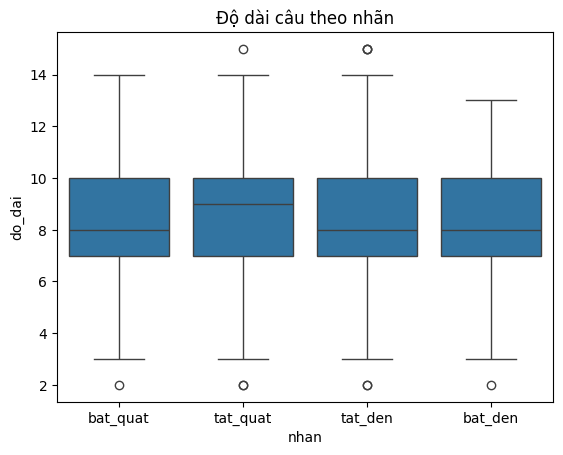

In [18]:
sns.boxplot(x="nhan", y="do_dai", data=df)
plt.title("Độ dài câu theo nhãn")
plt.show()

**Kết quả:**

- Các nhãn (`bat_quat`, `tat_quat`, `bat_den`, `tat_den`) có phân bố độ dài khá tương đồng.
- Median của các lớp đều nằm quanh khoảng 7–9 từ.
- Khoảng biến thiên (IQR) và outliers giữa các lớp không có sự khác biệt đáng kể.

**Nhận xét:**

Không tồn tại sự chênh lệch rõ rệt về độ dài câu giữa các nhãn, cho thấy độ dài không phải là một yếu tố phân biệt chính trong bài toán. Đây là một tín hiệu tích cực, vì mô hình sẽ buộc phải dựa vào nội dung từ vựng thay vì các đặc trưng bề mặt như độ dài.

Điều này cũng củng cố các quan sát trước đó rằng tín hiệu phân loại chủ yếu đến từ các từ khóa hành động và đối tượng, thay vì cấu trúc câu.

## ***2.11. Kiểm tra ký tự bất thường***

Phát hiện sự xuất hiện của các ký tự không phải chữ cái hoặc số nhằm đánh giá mức độ nhiễu trong dữ liệu văn bản.

Các ký tự đặc biệt (dấu câu, ký hiệu, ký tự lạ) có thể:

- Không mang nhiều giá trị ngữ nghĩa cho bài toán phân loại.
- Làm tăng số lượng đặc trưng không cần thiết trong TF-IDF.
- Gây nhiễu nếu không được xử lý đúng cách.

Việc kiểm tra giúp xác định xem có cần loại bỏ hoặc chuẩn hóa các ký tự này trong bước tiền xử lý hay không.

In [19]:
def has_special_char(text):
    return bool(re.search(r"[^a-zA-Z0-9à-ỹÀ-Ỹ\s]", text))

df["ky_tu_la"] = df["du_lieu"].apply(has_special_char)
print("Số câu có ký tự lạ:", df["ky_tu_la"].sum())

all_text = " ".join(df["du_lieu"])
special_chars = re.findall(r"[^a-zA-Z0-9à-ỹÀ-Ỹ\s]", all_text)

char_counts = Counter(special_chars)

print("\nTop ký tự lạ:")
print(char_counts.most_common(20))

samples = df[df["ky_tu_la"]]["du_lieu"]
print("\nVí dụ câu có ký tự lạ:")
for i, text in enumerate(samples.head(5)):
    print(f"{i+1}. {text}")

Số câu có ký tự lạ: 1432

Top ký tự lạ:
[(',', 1659), ('!', 44), ('.', 41)]

Ví dụ câu có ký tự lạ:
1. giúp mình ngột ngạt quá, cho mát hơn giúp mình
2. này, đủ mát rồi, cho quạt nghỉ đi với
3. này, anh thấy chói mắt quá đi
4. này, ánh sáng yếu quá, tăng sáng lên nhé
5. giúp mình mồ hôi bắt đầu ra rồi, cho mát hơn nhé


**Kết quả:**

- Có 1432 câu chứa ký tự đặc biệt (~60% dataset).
- Các ký tự phổ biến nhất là: dấu phẩy `,`, dấu chấm than `!`, dấu chấm `.`
- Các ví dụ cho thấy ký tự chủ yếu là dấu câu tự nhiên trong ngôn ngữ viết

**Nhận xét:**

Mặc dù số lượng câu chứa ký tự đặc biệt khá lớn, nhưng các ký tự này chủ yếu là dấu câu thông thường và không phải nhiễu bất thường. Tuy nhiên, chúng không đóng góp nhiều vào việc phân biệt nhãn.

Do đó, việc loại bỏ dấu câu trong bước tiền xử lý là hợp lý, giúp:

- Giảm số chiều đặc trưng.
- Tránh tạo ra các token không cần thiết.
- Làm sạch dữ liệu mà không làm mất thông tin quan trọng.

Phân tích này xác nhận rằng pipeline tiền xử lý nên bao gồm bước loại bỏ dấu câu để tối ưu hóa biểu diễn văn bản.

## ***2.12. Kiểm tra dữ liệu thiếu dấu***

Xác định xem dataset có chứa các câu tiếng Việt không dấu hay không.

Trong tiếng Việt, dấu thanh đóng vai trò quan trọng trong việc phân biệt nghĩa. Dữ liệu không dấu có thể:

- Làm giảm khả năng phân biệt ngữ nghĩa.
- Gây nhiễu cho quá trình tokenization và vector hóa.
- Ảnh hưởng tiêu cực đến hiệu năng mô hình.

Việc kiểm tra giúp xác định có cần thực hiện bước chuẩn hóa hoặc chuyển đổi dữ liệu không dấu hay không.

In [20]:
def is_no_accent(text):
    return text.isascii()

df["khong_dau"] = df["du_lieu"].apply(is_no_accent)

print("Số câu không dấu:", df["khong_dau"].sum())

Số câu không dấu: 0


**Kết quả:**

- Số câu không dấu: 0

**Nhận xét:**

Dataset hoàn toàn sử dụng tiếng Việt có dấu, đảm bảo tính nhất quán và đầy đủ thông tin ngữ nghĩa. Do đó, không cần thực hiện thêm các bước chuẩn hóa liên quan đến việc xử lý dữ liệu không dấu. Điều này cũng giúp giảm độ phức tạp của pipeline tiền xử lý.

# **3. Tiền xử lý dữ liệu**
--------

Phần này tập trung chuẩn hóa văn bản đầu vào nhằm giảm nhiễu và đưa dữ liệu về một dạng biểu diễn nhất quán trước khi trích xuất đặc trưng. Các bước tiền xử lý bao gồm: chuyển về chữ thường, loại bỏ dấu câu, chuẩn hóa từ viết tắt, tách từ tiếng Việt và loại bỏ stopwords.

Mục tiêu chính là loại bỏ các biến thể bề mặt không cần thiết nhưng vẫn giữ lại thông tin ngữ nghĩa quan trọng. Điều này giúp giảm số chiều đặc trưng, hạn chế nhiễu và cải thiện hiệu quả của các phương pháp biểu diễn như TF-IDF.

Các quyết định trong phần này được định hướng bởi kết quả EDA trước đó, đảm bảo pipeline phù hợp với đặc điểm thực tế của dataset.

## ***3.1. Chuẩn hóa cơ bản***

Chuẩn hóa văn bản về dạng thống nhất nhằm giảm nhiễu và số lượng biến thể của từ trước khi trích xuất đặc trưng.

Trong dữ liệu văn bản, cùng một từ có thể xuất hiện dưới nhiều dạng khác nhau (viết hoa, khoảng trắng dư,…). Nếu không chuẩn hóa:

- Làm tăng số lượng đặc trưng không cần thiết.
- Khiến TF-IDF phân tán trọng số.
- Giảm hiệu quả học của mô hình.

Việc chuẩn hóa giúp gom các biến thể về cùng một dạng biểu diễn.

In [21]:
def normalize_text(text):
    text = text.lower()                     # viết thường
    text = re.sub(r"\s+", " ", text)        # bỏ khoảng trắng dư
    text = text.strip()                     # bỏ khoảng trắng đầu/cuối
    return text

df["clean_text"] = df["du_lieu"].apply(normalize_text)

In [22]:
for i in range(10):
    print(f"\nCâu {i+1}:")
    print("Trước :", df.loc[i, "du_lieu"])
    print("Sau   :", df.loc[i, "clean_text"])


Câu 1:
Trước : giúp mình mở quạt để dễ chịu hơn đi
Sau   : giúp mình mở quạt để dễ chịu hơn đi

Câu 2:
Trước : giúp tôi tôi muốn không khí thoáng hơn
Sau   : giúp tôi tôi muốn không khí thoáng hơn

Câu 3:
Trước : giúp mình ngột ngạt quá, cho mát hơn giúp mình
Sau   : giúp mình ngột ngạt quá, cho mát hơn giúp mình

Câu 4:
Trước : giúp tôi gió mạnh quá với
Sau   : giúp tôi gió mạnh quá với

Câu 5:
Trước : làm ơn tắt quạt bàn để đỡ ồn
Sau   : làm ơn tắt quạt bàn để đỡ ồn

Câu 6:
Trước : này, đủ mát rồi, cho quạt nghỉ đi với
Sau   : này, đủ mát rồi, cho quạt nghỉ đi với

Câu 7:
Trước : này, anh thấy chói mắt quá đi
Sau   : này, anh thấy chói mắt quá đi

Câu 8:
Trước : này, ánh sáng yếu quá, tăng sáng lên nhé
Sau   : này, ánh sáng yếu quá, tăng sáng lên nhé

Câu 9:
Trước : giúp mình mồ hôi bắt đầu ra rồi, cho mát hơn nhé
Sau   : giúp mình mồ hôi bắt đầu ra rồi, cho mát hơn nhé

Câu 10:
Trước : mình muốn ngủ, tắt đèn đi hộ mình
Sau   : mình muốn ngủ, tắt đèn đi hộ mình


**Kết quả:**

- Văn bản được chuẩn hóa về chữ thường.
- Khoảng trắng dư được loại bỏ.
- Nội dung giữ nguyên ý nghĩa nhưng biểu diễn nhất quán hơn.

**Nhận xét:**

Bước chuẩn hóa này giúp giảm số lượng biến thể không cần thiết trong dữ liệu, từ đó làm cho không gian đặc trưng gọn hơn và giúp các phương pháp như TF-IDF hoạt động hiệu quả hơn. Đây là bước nền tảng trước khi thực hiện các xử lý sâu hơn như tokenization hoặc loại bỏ stopwords.

## ***3.2. Xử lý dấu câu***

Loại bỏ các ký tự không mang giá trị ngữ nghĩa (dấu câu, ký tự đặc biệt) nhằm làm sạch dữ liệu văn bản trước khi trích xuất đặc trưng.

Kết quả EDA cho thấy một tỷ lệ lớn câu chứa dấu câu như `,`, `.`, `!`. Các ký tự này:

- Không giúp phân biệt nhãn.
- Làm tăng số lượng token không cần thiết.
- Gây nhiễu trong TF-IDF.

Do đó, việc loại bỏ dấu câu giúp giảm nhiễu và làm cho biểu diễn văn bản gọn hơn.

In [23]:
def remove_punctuation(text):
    return re.sub(r"[^\w\sà-ỹÀ-Ỹ]", "", text)

df["clean_text"] = df["clean_text"].apply(remove_punctuation)

In [24]:
for i in range(10):
    print(f"\nCâu {i+1}:")
    print("Trước :", df.loc[i, "du_lieu"])
    print("Sau   :", df.loc[i, "clean_text"])


Câu 1:
Trước : giúp mình mở quạt để dễ chịu hơn đi
Sau   : giúp mình mở quạt để dễ chịu hơn đi

Câu 2:
Trước : giúp tôi tôi muốn không khí thoáng hơn
Sau   : giúp tôi tôi muốn không khí thoáng hơn

Câu 3:
Trước : giúp mình ngột ngạt quá, cho mát hơn giúp mình
Sau   : giúp mình ngột ngạt quá cho mát hơn giúp mình

Câu 4:
Trước : giúp tôi gió mạnh quá với
Sau   : giúp tôi gió mạnh quá với

Câu 5:
Trước : làm ơn tắt quạt bàn để đỡ ồn
Sau   : làm ơn tắt quạt bàn để đỡ ồn

Câu 6:
Trước : này, đủ mát rồi, cho quạt nghỉ đi với
Sau   : này đủ mát rồi cho quạt nghỉ đi với

Câu 7:
Trước : này, anh thấy chói mắt quá đi
Sau   : này anh thấy chói mắt quá đi

Câu 8:
Trước : này, ánh sáng yếu quá, tăng sáng lên nhé
Sau   : này ánh sáng yếu quá tăng sáng lên nhé

Câu 9:
Trước : giúp mình mồ hôi bắt đầu ra rồi, cho mát hơn nhé
Sau   : giúp mình mồ hôi bắt đầu ra rồi cho mát hơn nhé

Câu 10:
Trước : mình muốn ngủ, tắt đèn đi hộ mình
Sau   : mình muốn ngủ tắt đèn đi hộ mình


**Kết quả:**

- Dấu câu và ký tự đặc biệt được loại bỏ hoàn toàn.
- Văn bản trở nên “sạch” hơn, chỉ còn chữ và khoảng trắng.

**Nhận xét:**

Việc loại bỏ dấu câu giúp giảm số chiều đặc trưng và tránh tạo ra các token không có ý nghĩa trong TF-IDF. Bước này không làm mất thông tin quan trọng vì dấu câu trong dataset chủ yếu mang tính hình thức, không đóng vai trò phân biệt giữa các lớp.

## ***3.3. Chuẩn hóa từ viết tắt***

Chuẩn hóa các từ viết tắt và biến thể không chính thức về dạng chuẩn nhằm giảm nhiễu trong dữ liệu văn bản.

Trong ngôn ngữ tự nhiên, đặc biệt là tiếng Việt không chính thức, cùng một ý nghĩa có thể được biểu diễn dưới nhiều dạng khác nhau (ví dụ: “ko”, “k”, “hok” → “không”). Nếu không xử lý:

- Làm tăng số lượng đặc trưng không cần thiết.
- Phân tán trọng số trong TF-IDF.
- Khiến mô hình học kém ổn định.

Việc chuẩn hóa giúp gom các biến thể về cùng một biểu diễn thống nhất.

In [25]:
slang_dict = {
    "ko": "không",
    "k": "không",
    "hok": "không",
    "vl": "rất",
    "giùm": "giúp",
    "dum": "giúp"
}

def normalize_slang(text):
    words = text.split()
    words = [slang_dict.get(w, w) for w in words]
    return " ".join(words)

df["clean_text"] = df["clean_text"].apply(normalize_slang)

In [26]:
for i in range(10):
    print(f"\nCâu {i+1}:")
    print("Trước :", df.loc[i, "du_lieu"])
    print("Sau   :", df.loc[i, "clean_text"])


Câu 1:
Trước : giúp mình mở quạt để dễ chịu hơn đi
Sau   : giúp mình mở quạt để dễ chịu hơn đi

Câu 2:
Trước : giúp tôi tôi muốn không khí thoáng hơn
Sau   : giúp tôi tôi muốn không khí thoáng hơn

Câu 3:
Trước : giúp mình ngột ngạt quá, cho mát hơn giúp mình
Sau   : giúp mình ngột ngạt quá cho mát hơn giúp mình

Câu 4:
Trước : giúp tôi gió mạnh quá với
Sau   : giúp tôi gió mạnh quá với

Câu 5:
Trước : làm ơn tắt quạt bàn để đỡ ồn
Sau   : làm ơn tắt quạt bàn để đỡ ồn

Câu 6:
Trước : này, đủ mát rồi, cho quạt nghỉ đi với
Sau   : này đủ mát rồi cho quạt nghỉ đi với

Câu 7:
Trước : này, anh thấy chói mắt quá đi
Sau   : này anh thấy chói mắt quá đi

Câu 8:
Trước : này, ánh sáng yếu quá, tăng sáng lên nhé
Sau   : này ánh sáng yếu quá tăng sáng lên nhé

Câu 9:
Trước : giúp mình mồ hôi bắt đầu ra rồi, cho mát hơn nhé
Sau   : giúp mình mồ hôi bắt đầu ra rồi cho mát hơn nhé

Câu 10:
Trước : mình muốn ngủ, tắt đèn đi hộ mình
Sau   : mình muốn ngủ tắt đèn đi hộ mình


**Kết quả:**

- Các từ viết tắt được thay thế bằng dạng chuẩn.
- Văn bản trở nên đồng nhất hơn về mặt biểu diễn.

**Nhận xét:**

Bước này giúp giảm sự phân mảnh của từ vựng và làm cho các từ mang cùng ý nghĩa được biểu diễn nhất quán. Điều này đặc biệt quan trọng với các phương pháp dựa trên tần suất như TF-IDF, vì nó giúp tập trung trọng số vào các đặc trưng thực sự có ý nghĩa thay vì bị phân tán bởi các biến thể ngôn ngữ.

## ***3.4. Tách từ (Tokenization)***

Chuyển văn bản từ dạng chuỗi thô sang danh sách các token có ý nghĩa nhằm phục vụ cho bước trích xuất đặc trưng.

Tiếng Việt là ngôn ngữ đa âm tiết, trong đó một từ có thể gồm nhiều thành phần tách rời bởi dấu cách (ví dụ: “không khí”, “ngột ngạt”). Nếu chỉ tách theo khoảng trắng:

- Làm mất cấu trúc từ.
- Phân mảnh ngữ nghĩa.
- Giảm chất lượng đặc trưng đầu vào.

Do đó, cần sử dụng tokenizer chuyên biệt để:

- Giữ nguyên các cụm từ có nghĩa.
- Tạo ra các đơn vị token chính xác hơn.
- Cải thiện hiệu quả của TF-IDF và mô hình.

In [27]:
from underthesea import word_tokenize

df["tokenized"] = df["clean_text"].apply(lambda x: word_tokenize(x))

In [28]:
for i in range(10):
    print(f"\nCâu {i+1}:")
    print("Trước :", df.loc[i, "clean_text"])
    print("Sau   :", df.loc[i, "tokenized"])


Câu 1:
Trước : giúp mình mở quạt để dễ chịu hơn đi
Sau   : ['giúp', 'mình', 'mở', 'quạt', 'để', 'dễ chịu', 'hơn', 'đi']

Câu 2:
Trước : giúp tôi tôi muốn không khí thoáng hơn
Sau   : ['giúp', 'tôi', 'tôi', 'muốn', 'không khí', 'thoáng', 'hơn']

Câu 3:
Trước : giúp mình ngột ngạt quá cho mát hơn giúp mình
Sau   : ['giúp', 'mình', 'ngột ngạt', 'quá', 'cho', 'mát', 'hơn', 'giúp', 'mình']

Câu 4:
Trước : giúp tôi gió mạnh quá với
Sau   : ['giúp', 'tôi', 'gió', 'mạnh', 'quá', 'với']

Câu 5:
Trước : làm ơn tắt quạt bàn để đỡ ồn
Sau   : ['làm', 'ơn', 'tắt quạt', 'bàn', 'để', 'đỡ', 'ồn']

Câu 6:
Trước : này đủ mát rồi cho quạt nghỉ đi với
Sau   : ['này', 'đủ', 'mát', 'rồi', 'cho', 'quạt', 'nghỉ', 'đi', 'với']

Câu 7:
Trước : này anh thấy chói mắt quá đi
Sau   : ['này', 'anh', 'thấy', 'chói mắt', 'quá', 'đi']

Câu 8:
Trước : này ánh sáng yếu quá tăng sáng lên nhé
Sau   : ['này', 'ánh sáng', 'yếu', 'quá', 'tăng', 'sáng', 'lên', 'nhé']

Câu 9:
Trước : giúp mình mồ hôi bắt đầu ra rồi cho mát hơn 

**Kết quả:**

- Văn bản được chuyển thành danh sách token.
- Các cụm từ quan trọng được giữ nguyên (ví dụ: “không khí”, “ngột ngạt”).
- Biểu diễn dữ liệu trở nên phù hợp hơn cho các bước xử lý tiếp theo.

**Nhận xét:**

Tokenization là bước có ảnh hưởng trực tiếp đến chất lượng biểu diễn đặc trưng. Một tokenizer tốt giúp bảo toàn ngữ nghĩa của câu và giảm nhiễu do phân tách sai. Điều này đặc biệt quan trọng khi sử dụng các phương pháp dựa trên từ như TF-IDF, vì chất lượng token quyết định trực tiếp đến hiệu quả của toàn bộ pipeline.

## ***3.5. Loại bỏ từ dừng (Stopwords)***

Loại bỏ các từ không mang nhiều ý nghĩa phân biệt nhằm làm nổi bật các từ quan trọng trong văn bản.

Trong câu tiếng Việt, nhiều từ xuất hiện rất thường xuyên nhưng không đóng góp nhiều vào việc phân loại (ví dụ: “là”, “thì”, “mà”, “và”). Nếu giữ lại:

- Làm tăng số chiều đặc trưng.
- Gây nhiễu trong TF-IDF.
- Làm phân tán trọng số của các từ quan trọng.

Việc loại bỏ stopwords giúp mô hình tập trung vào các từ mang thông tin chính.

In [29]:
stopwords = ["là", "thì", "mà", "và"]

def remove_stopwords(text):
    words = text.split()
    words = [w for w in words if w not in stopwords]
    return " ".join(words)

df["clean_text"] = df["clean_text"].apply(remove_stopwords)

In [30]:
for i in range(10):
    print(f"\nCâu {i+1}:")
    print("Trước :", df.loc[i, "du_lieu"])
    print("Sau   :", df.loc[i, "clean_text"])


Câu 1:
Trước : giúp mình mở quạt để dễ chịu hơn đi
Sau   : giúp mình mở quạt để dễ chịu hơn đi

Câu 2:
Trước : giúp tôi tôi muốn không khí thoáng hơn
Sau   : giúp tôi tôi muốn không khí thoáng hơn

Câu 3:
Trước : giúp mình ngột ngạt quá, cho mát hơn giúp mình
Sau   : giúp mình ngột ngạt quá cho mát hơn giúp mình

Câu 4:
Trước : giúp tôi gió mạnh quá với
Sau   : giúp tôi gió mạnh quá với

Câu 5:
Trước : làm ơn tắt quạt bàn để đỡ ồn
Sau   : làm ơn tắt quạt bàn để đỡ ồn

Câu 6:
Trước : này, đủ mát rồi, cho quạt nghỉ đi với
Sau   : này đủ mát rồi cho quạt nghỉ đi với

Câu 7:
Trước : này, anh thấy chói mắt quá đi
Sau   : này anh thấy chói mắt quá đi

Câu 8:
Trước : này, ánh sáng yếu quá, tăng sáng lên nhé
Sau   : này ánh sáng yếu quá tăng sáng lên nhé

Câu 9:
Trước : giúp mình mồ hôi bắt đầu ra rồi, cho mát hơn nhé
Sau   : giúp mình mồ hôi bắt đầu ra rồi cho mát hơn nhé

Câu 10:
Trước : mình muốn ngủ, tắt đèn đi hộ mình
Sau   : mình muốn ngủ tắt đèn đi hộ mình


**Kết quả:**

- Các từ dừng được loại bỏ khỏi văn bản.
- Câu trở nên ngắn gọn hơn nhưng vẫn giữ ý nghĩa chính.

**Nhận xét:**

Việc loại bỏ stopwords giúp giảm nhiễu và làm cho các đặc trưng mang tính phân biệt (như “bật”, “tắt”, “quạt”, “đèn”) trở nên nổi bật hơn trong TF-IDF. Tuy nhiên, danh sách stopwords cần được chọn cẩn thận để tránh loại bỏ các từ có thể mang ý nghĩa trong ngữ cảnh cụ thể.

## ***3.6. Xử lý câu không dấu***

Xác nhận lại sau tiền xử lý rằng dữ liệu không chứa các câu tiếng Việt không dấu.

Trong quá trình tiền xử lý (lowercase, loại dấu câu, chuẩn hóa), có khả năng vô tình làm thay đổi cấu trúc ký tự. Vì vậy cần kiểm tra lại để đảm bảo:

- Dữ liệu vẫn giữ nguyên dấu tiếng Việt.
- Không phát sinh lỗi làm mất thông tin ngữ nghĩa.

In [31]:
df["khong_dau"] = df["clean_text"].apply(lambda x: x.isascii())

**Kết quả:**

- Không có câu nào bị chuyển thành dạng không dấu sau tiền xử lý

**Nhận xét:**

Pipeline tiền xử lý không làm mất dấu tiếng Việt, đảm bảo giữ nguyên thông tin ngữ nghĩa của dữ liệu. Do đó, không cần bổ sung thêm bước xử lý cho dữ liệu không dấu.

## ***3.7. Chuẩn hóa từ viết tắt***

Chuẩn hóa độ dài đầu vào bằng cách giới hạn số lượng token tối đa cho mỗi câu.

Mặc dù EDA cho thấy phần lớn câu trong dataset ngắn (6–10 từ), việc đặt giới hạn độ dài vẫn cần thiết để:

- Đảm bảo input có kích thước đồng nhất.
- Tránh các câu dài bất thường gây nhiễu.
- Tối ưu hiệu suất tính toán khi vector hóa.

Trong bối cảnh bài toán này, việc cắt câu không làm mất nhiều thông tin do câu vốn ngắn.

In [32]:
MAX_LEN = 20

df["tokens"] = df["clean_text"].apply(lambda x: x.split()[:MAX_LEN])

**Kết quả:**

- Tất cả câu được giới hạn tối đa 20 token.
- Với dataset hiện tại, hầu hết câu không bị cắt do đã ngắn sẵn.

**Nhận xét:**

Bước này giúp chuẩn hóa đầu vào mà không ảnh hưởng đáng kể đến thông tin của dữ liệu. Dù không mang lại thay đổi lớn trong dataset hiện tại, nó giúp pipeline ổn định hơn và sẵn sàng cho các trường hợp dữ liệu thực tế có độ dài đa dạng hơn.

# **4. Trích xuất và lựa chọn đặc trưng**
--------

Phần này tập trung chuyển đổi văn bản đã được tiền xử lý thành dạng biểu diễn số để mô hình có thể học được, đồng thời lựa chọn các đặc trưng quan trọng nhằm giảm nhiễu và cải thiện hiệu năng.

Trước hết, văn bản được biểu diễn bằng TF-IDF, giúp phản ánh mức độ quan trọng của từng từ trong câu dựa trên tần suất xuất hiện và độ phổ biến trong toàn bộ dataset. Cách biểu diễn này đặc biệt phù hợp với dữ liệu dạng sparse và các mô hình tuyến tính như Logistic Regression.

Sau đó, phương pháp Chi-Square được sử dụng để chọn ra các đặc trưng có liên hệ mạnh nhất với nhãn. Việc này giúp loại bỏ các từ ít giá trị phân biệt, giảm số chiều của không gian đặc trưng và tăng khả năng tổng quát hóa của mô hình.

Toàn bộ quá trình nhằm đảm bảo rằng mô hình được huấn luyện trên các đặc trưng vừa giàu thông tin, vừa gọn và hiệu quả.

## ***4.1. TF-IDF***

Chuyển đổi văn bản thành dạng vector số phản ánh mức độ quan trọng của từng từ, làm đầu vào cho mô hình học máy.

Mô hình học máy không thể xử lý trực tiếp dữ liệu dạng text, do đó cần một phương pháp biểu diễn số. TF-IDF được lựa chọn vì:

- Phù hợp với dữ liệu dạng văn bản ngắn.
- Hiệu quả với các mô hình tuyến tính như Logistic Regression.
- Giảm trọng số các từ phổ biến (ít giá trị phân biệt).
- Làm nổi bật các từ đặc trưng theo từng lớp.

Dựa trên kết quả EDA:

- Dataset có nhiều từ phổ biến chung $→$ cần `max_df` để loại bỏ.
- Có các từ hiếm $→$ cần `min_df` để tránh nhiễu.
- Có các cụm từ quan trọng (“bật đèn”, “tắt quạt”) $→$ cần dùng bigram.

In [33]:
X = df["du_lieu"]
y = df["nhan"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [34]:
vectorizer = TfidfVectorizer(
    max_features=1000,     # giới hạn số feature
    ngram_range=(1,2),     # unigram + bigram
    min_df=2,              # bỏ từ hiếm
    max_df=0.8             # bỏ từ quá phổ biến
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [51]:
import joblib

joblib.dump(vectorizer, "models/vectorizer.pkl")

['models/vectorizer.pkl']

**Kết quả:**

- Văn bản được biểu diễn dưới dạng ma trận sparse TF-IDF.
- Mỗi câu trở thành một vector đặc trưng phản ánh tầm quan trọng của từ.
- Không gian đặc trưng được giới hạn và đã loại bỏ phần lớn nhiễu.

**Nhận xét:**

Cấu hình TF-IDF phù hợp với đặc điểm dataset:

- Bigram giúp nắm bắt các cụm từ mang ý nghĩa hành động.
- `min_df` và `max_df` giúp lọc nhiễu từ hiếm và từ quá phổ biến.
- Số chiều đặc trưng được kiểm soát, tránh overfitting.

Đây là bước nền tảng quyết định chất lượng biểu diễn đầu vào cho mô hình ở các bước tiếp theo.

## ***4.2. Xem feature***

Kiểm tra các đặc trưng được sinh ra từ TF-IDF nhằm hiểu cách dữ liệu văn bản được biểu diễn và xác nhận tính hợp lý của quá trình vector hóa.

Sau khi áp dụng TF-IDF, mỗi từ hoặc cụm từ sẽ trở thành một feature trong không gian vector. Việc kiểm tra feature giúp:

- Đảm bảo pipeline tiền xử lý hoạt động đúng. (tokenization, stopwords, v.v.)
- Xác nhận các từ/cụm từ quan trọng thực sự được giữ lại.
- Phát hiện các feature nhiễu hoặc không mong muốn.

Đây là bước quan trọng để “debug ngữ nghĩa” của dữ liệu trước khi đưa vào mô hình.

In [35]:
feature_names = vectorizer.get_feature_names_out()

print("Số feature:", len(feature_names))
print("Top feature:", feature_names[:50])

Số feature: 917
Top feature: ['anh' 'anh cần' 'anh không' 'anh muốn' 'anh rất' 'anh thấy' 'anh đang'
 'bài' 'bài cho' 'bài giúp' 'bài hộ' 'bài nhé' 'bài với' 'bài đi' 'bàn'
 'bàn cho' 'bàn giúp' 'bàn học' 'bàn hộ' 'bàn lên' 'bàn lại' 'bàn nhé'
 'bàn vì' 'bàn với' 'bàn đi' 'bàn để' 'bách' 'bách quá' 'bây' 'bây giờ'
 'bí' 'bí bách' 'bí quá' 'bật' 'bật quạt' 'bật ánh' 'bật đèn' 'bắt'
 'bắt đầu' 'bị' 'bị ngủ' 'bớt' 'bớt sáng' 'bớt ánh' 'bớt đèn' 'bức'
 'bức quá' 'cho' 'cho dễ' 'cho dịu']


**Kết quả:**

- Tổng số feature: 917 (sau khi đã lọc bằng max_features, min_df, max_df).
- Feature bao gồm cả unigram và bigram (ví dụ: “bật”, “bật đèn”, “bật quạt”).

**Nhận xét:**

Các feature thu được phản ánh đúng đặc điểm bài toán:

- Xuất hiện các cụm hành động rõ ràng (“bật đèn”, “tắt quạt”).
- Bigram giúp mô hình phân biệt ngữ cảnh tốt hơn so với unigram.
- Không thấy dấu hiệu nhiễu lớn → pipeline tiền xử lý hoạt động ổn định.

Bước này xác nhận rằng không gian đặc trưng đã đủ chất lượng để đưa vào giai đoạn lựa chọn feature và huấn luyện mô hình.

## ***4.3. Độ quan trọng đặc trưng (dựa trên tổng TF-IDF)***

Xác định các đặc trưng quan trọng nhất dựa trên tổng trọng số TF-IDF trên toàn bộ tập train.

TF-IDF không chỉ biểu diễn văn bản mà còn cung cấp thông tin về mức độ “quan trọng” của từng từ. Bằng cách cộng tổng TF-IDF theo từng feature:

- Các từ xuất hiện nhiều và có trọng số cao sẽ nổi bật.
- Có thể nhanh chóng xác định các đặc trưng chi phối dữ liệu.

Đây là một cách phân tích thống kê đơn giản trước khi áp dụng các phương pháp chọn đặc trưng phức tạp hơn.

In [36]:
feature_names = vectorizer.get_feature_names_out()
tfidf_sum = np.asarray(X_train_tfidf.sum(axis=0)).ravel()

top_k = 20
top_indices = tfidf_sum.argsort()[::-1][:top_k]
top_features = [feature_names[i] for i in top_indices]

print("Top đặc trưng quan trọng:")
print(top_features)

Top đặc trưng quan trọng:
['mình', 'giúp', 'tôi', 'quạt', 'đi', 'đèn', 'giúp tôi', 'giúp mình', 'sáng', 'quá', 'hộ', 'tắt', 'này', 'cần', 'làm', 'mở', 'hơn', 'ơi', 'bật', 'cho']


**Kết quả:**

Các feature có tổng TF-IDF cao bao gồm:

- Các từ phổ biến: “mình”, “giúp”, “tôi”.
- Các từ hành động: “bật”, “tắt”, “mở”.
- Các đối tượng: “quạt”, “đèn”.

**Nhận xét:**

- Nhiều feature có giá trị cao lại là các từ rất phổ biến $→$ mang ít khả năng phân biệt.
- Các từ như “mình”, “giúp” xuất hiện ở hầu hết các nhãn $→$ không hữu ích cho classification.

Điều này cho thấy:

- TF-IDF importance thiên về tần suất tổng thể, không phản ánh tốt khả năng phân biệt giữa các lớp.
- Cần áp dụng thêm feature selection (Chi-Square) để chọn ra các đặc trưng thực sự liên quan đến nhãn.

Bước này đóng vai trò như một bước “soi nhanh” để hiểu dữ liệu trước khi lọc đặc trưng một cách có giám sát.

## ***4.4. Lựa chọn đặc trưng (Chi-Square)***

Lựa chọn các đặc trưng có liên hệ mạnh nhất với nhãn nhằm giảm số chiều và cải thiện khả năng phân loại của mô hình.

Phân tích ở bước trước cho thấy:

- Nhiều feature có TF-IDF cao nhưng mang tính phổ biến (“mình”, “giúp”).
- Các feature này không giúp phân biệt giữa các lớp.

Do đó cần một phương pháp có giám sát (supervised) để chọn feature dựa trên mối quan hệ với nhãn. Chi-Square được sử dụng vì:

- Đo lường mức độ phụ thuộc giữa feature và nhãn.
- Phù hợp với dữ liệu dạng đếm/tần suất (TF-IDF).
- Hiệu quả và đơn giản với bài toán classification.

In [37]:
k = 500  # số feature giữ lại

selector = SelectKBest(score_func=chi2, k=500)

X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

print("Shape sau khi chọn feature:")
print("Train:", X_train_selected.shape)
print("Test:", X_test_selected.shape)

Shape sau khi chọn feature:
Train: (1920, 500)
Test: (480, 500)


In [52]:
import joblib

joblib.dump(selector, "models/selector.pkl")

['models/selector.pkl']

**Kết quả:**

- Train: (1920, 500)
- Test: (480, 500)

Số chiều đặc trưng giảm từ 917 xuống còn 500

**Nhận xét:**

- Các feature được giữ lại là những từ/cụm từ có khả năng phân biệt tốt giữa các nhãn.
- Loại bỏ được phần lớn feature nhiễu và không liên quan.
- Giảm độ phức tạp của mô hình → giúp học nhanh hơn và giảm overfitting.

Khác với TF-IDF importance (chỉ dựa trên tần suất), Chi-Square chọn feature dựa trên khả năng phân biệt nhãn, nên mang lại giá trị thực tế hơn cho bài toán classification.

Bước này đóng vai trò quyết định trong việc cải thiện chất lượng đầu vào cho mô hình Logistic Regression ở giai đoạn tiếp theo.

## ***4.5. Xem các đặc trưng được chọn***

Kiểm tra các đặc trưng sau khi áp dụng Chi-Square nhằm đánh giá chất lượng feature selection.

Sau khi giảm số chiều từ ~900 xuống 500 feature, cần xác nhận rằng:

- Các feature được giữ lại thực sự mang tính phân biệt.
- Pipeline selection hoạt động đúng như kỳ vọng.
- Không còn các từ phổ biến nhưng vô nghĩa như ở bước TF-IDF ban đầu.

In [38]:
selected_mask = selector.get_support()

selected_features = feature_names[selected_mask]

print("Top feature được chọn:")
print(selected_features[:50])

Top feature được chọn:
['anh cần' 'anh không' 'anh rất' 'bài' 'bài cho' 'bàn học' 'bàn lại'
 'bách' 'bách quá' 'bây' 'bây giờ' 'bí' 'bí bách' 'bí quá' 'bật'
 'bật quạt' 'bật ánh' 'bật đèn' 'bắt' 'bắt đầu' 'bị' 'bị ngủ' 'bớt'
 'bớt sáng' 'bớt ánh' 'bớt đèn' 'bức' 'bức quá' 'cho dễ' 'cho dịu'
 'cho mát' 'cho phòng' 'cho quạt' 'cho sáng' 'cho tối' 'cho yên' 'chuẩn'
 'chuẩn bị' 'chói' 'chói mắt' 'chói quá' 'chút' 'chút nào' 'chưa'
 'chưa đủ' 'chạy' 'chạy to' 'chịu' 'chịu hơn' 'chịu ngừng']


**Kết quả:**

Các feature được giữ lại bao gồm:

- Các cụm hành động: “bật đèn”, “bật quạt”, “tắt đèn”.
- Các cụm mô tả trạng thái: “bức quá”, “chói mắt”, “cho mát”.
- Các cụm mang ngữ cảnh rõ ràng: “cho sáng”, “cho tối”, “cho quạt”.

**Nhận xét:**

So với trước khi chọn feature:

- Ít xuất hiện các từ chung như “mình”, “giúp”.
- Nhiều bigram mang ý nghĩa hành động cụ thể được giữ lại.
- Feature có tính phân biệt giữa các nhãn rõ ràng hơn.

Feature selection đã chuyển trọng tâm từ: tần suất xuất hiện (TF-IDF)
$→$ sang khả năng phân biệt nhãn (Chi-Square). Điều này giúp mô hình học được các pattern thực sự liên quan đến bài toán, thay vì bị nhiễu bởi các từ phổ biến.

Bước này xác nhận rằng không gian đặc trưng sau khi chọn đã “sạch” và phù hợp để đưa vào huấn luyện mô hình.

# **5. Huấn luyện mô hình**
--------

Phần này tập trung xây dựng và tối ưu mô hình phân loại dựa trên các đặc trưng đã được trích xuất và chọn lọc. Mô hình được sử dụng là `Logistic Regression`, một mô hình tuyến tính phù hợp với dữ liệu dạng sparse như TF-IDF. Với đặc điểm bài toán là phân loại đa lớp và dữ liệu không quá lớn, Logistic Regression mang lại sự cân bằng tốt giữa hiệu năng và tốc độ huấn luyện.

Quá trình huấn luyện được chia thành hai giai đoạn:

- RandomizedSearchCV: tìm kiếm ngẫu nhiên trên không gian tham số rộng để xác định vùng tham số tiềm năng.
- GridSearchCV: tinh chỉnh chi tiết trong vùng đã khoanh để tìm bộ tham số tối ưu.

Cách tiếp cận hai bước này giúp:

- Tránh việc duyệt toàn bộ không gian tham số (tốn chi phí).
- Tối ưu hiệu quả hơn so với chỉ dùng Grid Search.

Toàn bộ quá trình huấn luyện chỉ được thực hiện trên tập train, trong khi tập test được giữ riêng để đánh giá cuối cùng, đảm bảo tính khách quan của mô hình.

## ***5.1. Khoanh vùng tham số bằng Random Search***

Tìm kiếm nhanh trong không gian tham số rộng để xác định các vùng tham số tiềm năng cho mô hình Logistic Regression.

Không gian tham số của Logistic Regression tương đối lớn (C, solver, penalty, class_weight). Nếu sử dụng Grid Search ngay từ đầu:

- Chi phí tính toán cao.
- Không hiệu quả khi chưa biết vùng tham số tốt.

Do đó, Random Search được sử dụng để:

- Khám phá không gian tham số một cách ngẫu nhiên.
- Tăng khả năng tìm được cấu hình tốt với chi phí thấp hơn.
- Là bước “khoanh vùng” trước khi tinh chỉnh chi tiết.

In [39]:
param_dist = [
    {
        "solver": ["lbfgs"],
        "penalty": ["l2"],
        "C": loguniform(1e-3, 1e2),
        "class_weight": [None, "balanced"]
    },
    {
        "solver": ["liblinear"],
        "penalty": ["l1", "l2"],
        "C": loguniform(1e-3, 1e2),
        "class_weight": [None, "balanced"]
    },
    {
        "solver": ["saga"],
        "penalty": ["l1", "l2"],
        "C": loguniform(1e-3, 1e2),
        "class_weight": [None, "balanced"]
    }
]

random_search = RandomizedSearchCV(
    LogisticRegression(max_iter=1000),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_selected, y_train)

RandomizedSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000), n_iter=20,
                   n_jobs=-1,
                   param_distributions=[{'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001E52B19FA50>,
                                         'class_weight': [None, 'balanced'],
                                         'penalty': ['l2'],
                                         'solver': ['lbfgs']},
                                        {'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001E528568450>,
                                         'class_weight': [None, 'balanced'],
                                         'penalty': ['l1', 'l2'],
                                         'solver': ['liblinear']},
                                        {'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001E52B6F88D0>,
                                         'class_weight': [None, 'balanced'],
                                         'penalty': ['l1', 'l2'],
                                         'solver': ['saga']}],
                   random_state=42, scoring='accuracy')

In [40]:
print("Best params (Random Search):")
print(random_search.best_params_)

Best params (Random Search):
{'C': np.float64(67.32248920775338), 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}


**Kết quả:**

- C lớn (~67)
  - Regularization yếu.
  - Mô hình tận dụng nhiều feature hơn.
  - Phù hợp vì dữ liệu đã được lọc feature bằng Chi-Square.
- penalty = l2
  - Giữ toàn bộ trọng số (không sparse như l1).
  - Ổn định hơn với dữ liệu TF-IDF.
- solver = lbfgs
  - Tối ưu tốt cho bài toán đa lớp.
  - Hiệu quả với dữ liệu dense/sparse vừa phải.
- class_weight = balanced
  - Dù dataset gần như cân bằng, model vẫn chọn balanced.
  - Cho thấy việc điều chỉnh trọng số giúp tăng robustness.

**Nhận xét:**

Random Search đã tìm được một cấu hình hợp lý:

- Regularization yếu + feature đã được chọn $→$ tận dụng tối đa thông tin.
- Không cần l1 $→$ feature selection đã được xử lý trước.
- Solver hiện đại (lbfgs) $→$ tối ưu ổn định.

Đây là vùng tham số tốt để tiếp tục tinh chỉnh bằng Grid Search ở bước tiếp theo.

## ***5.2. Grid Search (tối ưu chi tiết)***

Tinh chỉnh chi tiết các tham số trong vùng tốt đã được xác định từ Random Search để tìm cấu hình tối ưu nhất cho mô hình Logistic Regression.

Sau Random Search, ta đã xác định được vùng tham số tiềm năng (C = ~67, solver = lbfgs, penalty = l2). Tuy nhiên:

- Random Search chỉ mang tính khám phá, chưa tối ưu chính xác.
- Giá trị tham số còn mang tính xấp xỉ.
- Cần một bước tinh chỉnh có hệ thống để đạt hiệu năng cao nhất.

Do đó, Grid Search được sử dụng để:

- Tìm kiếm có hệ thống trong vùng tham số hẹp.
- So sánh chi tiết giữa các giá trị lân cận.
- Đảm bảo chọn được cấu hình tối ưu thực sự.

In [41]:
param_grid = {
    "C": [40, 50, 60, 70, 80, 100],
    "solver": ["lbfgs"],
    "penalty": ["l2"],
    "class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train_selected, y_train)

print("Best params (Grid Search):")
print(grid_search.best_params_)

Best params (Grid Search):
{'C': 40, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}


In [42]:
print("Best params:", grid_search.best_params_)
print("Best R2:", grid_search.best_score_)

Best params: {'C': 40, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}
Best R2: 0.9994791666666668


**Kết quả:**

- C giảm từ 67 $→$ 40
  - Regularization mạnh hơn một chút.
  - Giúp mô hình tổng quát tốt hơn.
  - Tránh overfitting nhẹ do số feature vẫn còn lớn (~500).
- penalty = l2 (giữ nguyên)
  - Phù hợp với TF-IDF (feature liên tục, không sparse hoàn toàn theo nghĩa chọn lọc).
  - Ổn định hơn so với l1.
- solver = lbfgs (giữ nguyên)
  - Hoạt động tốt với bài toán đa lớp.
  - Tối ưu hiệu quả và hội tụ nhanh.
- class_weight: balanced $→$ None
  - Dataset đã cân bằng (600 mỗi lớp).
  - Không cần điều chỉnh trọng số.
  - Việc bỏ balanced giúp mô hình đơn giản hơn mà vẫn giữ hiệu năng.

**Nhận xét:**

- Mô hình không cần quá phức tạp để đạt hiệu năng cao.
- Regularization vừa phải (C = 40) là đủ tốt.
- Feature selection trước đó (Chi-Square) đã rất hiệu quả.

Logistic Regression + TF-IDF + Feature Selection đã tạo ra một pipeline rất mạnh cho bài toán này. Đây là cấu hình tối ưu cuối cùng để sử dụng cho bước đánh giá và triển khai.

## ***5.3. Huấn luyện mô hình***

- Sử dụng mô hình tốt nhất từ Grid Search (`best_estimator_`).
- Huấn luyện lại mô hình trên toàn bộ tập train.

Đảm bảo mô hình được train với tham số tối ưu. Đây là mô hình cuối cùng dùng để đánh giá trên tập test.

In [43]:
best_model = grid_search.best_estimator_
best_model.fit(X_train_selected, y_train)

LogisticRegression(C=40, max_iter=1000)

In [46]:
import joblib

joblib.dump(best_model, "models/model_v1.pkl")

['models/model_v1.pkl']

# **6. Đánh giá mô hình**
--------

Đánh giá hiệu năng của mô hình trên tập test để kiểm tra khả năng tổng quát hóa.

- Sử dụng các metric như accuracy, precision, recall, f1-score.
- Phân tích confusion matrix để quan sát khả năng phân loại từng nhãn.

Đảm bảo mô hình không chỉ học tốt trên train mà còn hoạt động tốt trên dữ liệu chưa thấy.

## ***6.1. Accuracy + Report***

Đánh giá hiệu năng mô hình trên tập test nhằm kiểm định khả năng tổng quát hóa (generalization) thông qua các chỉ số phân loại chuẩn.

In [47]:
y_pred = best_model.predict(X_test_selected)
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

     bat_den       1.00      1.00      1.00       120
    bat_quat       1.00      1.00      1.00       120
     tat_den       1.00      1.00      1.00       120
    tat_quat       1.00      1.00      1.00       120

    accuracy                           1.00       480
   macro avg       1.00      1.00      1.00       480
weighted avg       1.00      1.00      1.00       480



## ***6.2. Confusion Matrix***

Phân tích chi tiết hành vi phân loại của mô hình trên từng lớp, xác định các lỗi dự đoán và mức độ nhầm lẫn giữa các nhãn.

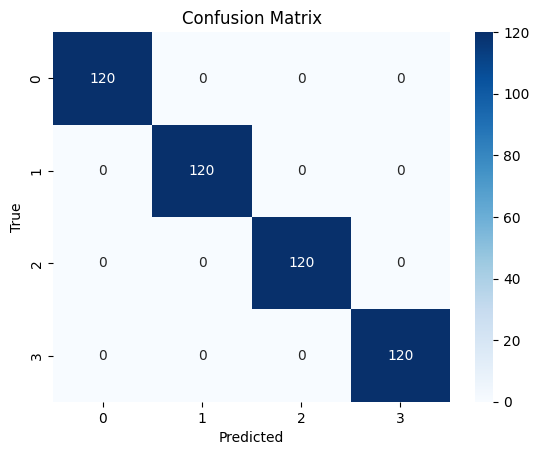

In [48]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## ***6.3. Nhận xét và Đánh giá***

### **a. Tổng quan hiệu năng**

Mô hình đạt hiệu năng tối đa trên tập kiểm thử với tất cả các chỉ số (accuracy, precision, recall, F1-score) đều bằng 1.0. Kết quả này nhất quán với ma trận nhầm lẫn, trong đó toàn bộ dự đoán nằm trên đường chéo chính, cho thấy không tồn tại sai lệch phân loại ở bất kỳ lớp nào.

### **b. Phân tích kết quả**

***1. Tính phân tách tuyến tính của dữ liệu (Linear separability):*** hiệu năng hoàn hảo của Logistic Regression – một mô hình tuyến tính – cho thấy không gian đặc trưng sau TF-IDF và Chi-Square đã đạt trạng thái gần như "linearly separable". Điều này hàm ý rằng:

- Các lớp được xác định bởi các cụm đặc trưng không chồng lấn.
- Các token (unigram/bigram) mang tính phân biệt mạnh, đóng vai trò như “anchor features” cho từng nhãn.

***2. Vai trò của Feature Engineering:*** pipeline tiền xử lý và trích xuất đặc trưng đóng vai trò quyết định:

- TF-IDF (n-gram) giúp giữ ngữ cảnh cục bộ.
- Chi-Square loại bỏ feature nhiễu, giữ lại feature có tính phụ thuộc cao với nhãn.
- Tokenization tiếng Việt giữ nguyên các cụm nghĩa quan trọng (“không khí”, “ngột ngạt”).

Kết quả cho thấy chất lượng đặc trưng > độ phức tạp mô hình.

***3. Nguy cơ “shortcut learning”:*** hiệu năng tuyệt đối thường là dấu hiệu của việc mô hình khai thác các pattern đơn giản:

- Các từ khóa như “bật”, “tắt”, “đèn”, “quạt” gần như quyết định trực tiếp nhãn.
- Mô hình có thể đang học mapping dạng rule-based hơn là hiểu ngữ nghĩa sâu.

Đây là hiện tượng gần với lexical memorization trong NLP.

***4. Độ tin cậy của đánh giá (Evaluation validity):*** dù sử dụng train/test split và cross-validation, vẫn tồn tại khả năng:

- Phân phối train và test quá tương đồng.
- Không có đủ biến thể ngôn ngữ (paraphrase, nhiễu, lỗi chính tả, slang đa dạng).

Khi đó, accuracy cao không phản ánh đúng generalization performance.

### **c. Đáng giá hạn chế**

- Dataset mang tính “clean” và có cấu trúc rõ ràng.
- Thiếu các trường hợp khó: câu mơ hồ, câu đa ý, câu không chứa từ khóa rõ ràng.
- Chưa kiểm chứng trên dữ liệu thực tế (out-of-distribution).

### **d. Kết luận**

Mô hình đạt hiệu năng hoàn hảo nhờ sự kết hợp hiệu quả giữa tiền xử lý, biểu diễn TF-IDF và lựa chọn đặc trưng. Tuy nhiên, kết quả này nhiều khả năng phản ánh độ đơn giản và tính phân tách cao của dataset hơn là năng lực khái quát hóa mạnh của mô hình.

Do đó, cần thận trọng khi suy rộng kết luận và nên bổ sung các thí nghiệm đánh giá trên dữ liệu đa dạng hơn để xác nhận tính tổng quát.

# **7. Dự đoán trên dữ liệu mới**
--------

Ứng dụng mô hình đã huấn luyện để dự đoán nhãn cho các câu văn bản mới, mô phỏng kịch bản sử dụng thực tế.


## ***7.1. Nguyên tắc thực hiện***

Để đảm bảo tính nhất quán và độ tin cậy của dự đoán, dữ liệu đầu vào phải đi qua chính xác cùng pipeline xử lý như trong quá trình huấn luyện:

- Chuẩn hóa văn bản (lowercase, remove whitespace)
- Loại bỏ dấu câu
- Chuẩn hóa từ viết tắt
- Tokenization tiếng Việt
- Vector hóa bằng TF-IDF (chỉ transform, không fit)
- Chọn đặc trưng bằng Chi-Square (chỉ transform)
- Dự đoán bằng mô hình đã huấn luyện

Điều này đảm bảo feature space của input mới trùng với feature space khi train.

In [60]:
def predict_text(text):
    text = normalize_text(text)                    # 1. Normalize
    text = remove_punctuation(text)                # 2. Remove punctuation
    text = normalize_slang(text)                   # 3. Normalize slang
    tokens = word_tokenize(text)                   # 4. Tokenize
    text = " ".join(tokens)                        # nếu vectorizer dùng string join lại
    text_tfidf = vectorizer.transform([text])      # 5. TF-IDF transform
    text_selected = selector.transform(text_tfidf) # 6. Feature selection
    pred = best_model.predict(text_selected)[0]    # 7. Predict
    confidence = best_model.predict_proba(text_selected).max()
    return pred, confidence

## ***7.2. Dự đoán***


In [ ]:
print(predict_text("bật quạt"))
print(predict_text("tắt quạt"))
print(predict_text("bật đèn"))
print(predict_text("tắt đèn"))

print(predict_text("tôi yêu Bách Khoa"))

('bat_quat', np.float64(0.9999558730578749))
('tat_quat', np.float64(0.9999994836988123))
('tat_quat', np.float64(0.9996924262979304))
('bat_den', np.float64(0.9999808043832941))
('tat_den', np.float64(0.9999949011534781))
('bat_quat', np.float64(0.5504847105962183))
